# Comparisons of models
Comparisons of some of the experimented models are located here.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import xarray
import torch
import pathlib
import matplotlib

import models
import loss

Prepare the data from validation set

In [2]:
RESAMPLING = rasterio.enums.Resampling.average
PATH = '/rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/'
SCALE_FACTOR = 16

Y = xarray.open_mfdataset(PATH + "TM/*.nc", decode_coords="all", decode_timedelta=False)
Y = Y['TM']

# validation set
Y = Y.sel(time=slice('1993', '2002'))

# crop
Y = Y.isel(easting=slice(0, 400), northing=slice(0, 400))
Y.rio.set_spatial_dims("easting", "northing")

# upscaled version in X
resolution = SCALE_FACTOR * 1_000
X = Y.rio.reproject(
    Y.rio.crs, resolution=(resolution, resolution), resampling=RESAMPLING
)

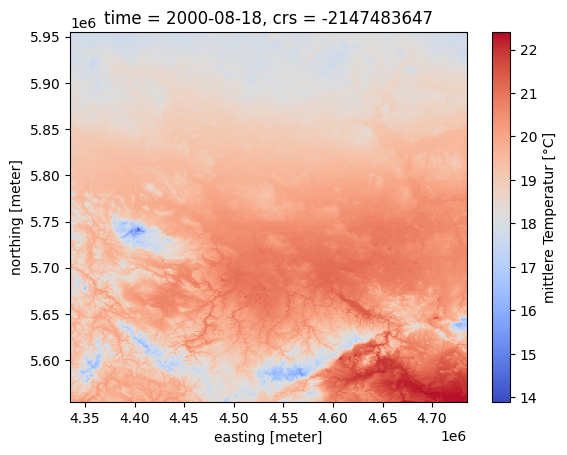

In [3]:
DATE = '2000-8-18'
Y.sel(time=DATE).plot(cmap = 'coolwarm')

Functions to load models

In [4]:
torch.set_float32_matmul_precision("high")

CKPT_DIR = '/home/tomas/ctu/current/rci_home/SISR-downscaling/logs/lightning_logs/'


def load_checkpoint(version: int):
    dir = pathlib.Path(CKPT_DIR + f'version_{version}/checkpoints/')
    return [file for file in dir.iterdir() if file.is_file() and file.suffix == '.ckpt'][0]

def load_model(version: int):
    ckpt = load_checkpoint(version)

    model = models.ConstrainedModel.load_from_checkpoint(checkpoint_path = ckpt,
                                                         model=models.EDSR(channels=1, scale_factor=SCALE_FACTOR, features=128, residual_blocks=64, loss=loss.LossCombination([1], [
                                                             loss.L1Loss()])),
                                                         constraint=models.AddConstraintLayer(SCALE_FACTOR)).cuda()
    model.eval()
    return model

Downscale a specific day with a model

In [5]:
def downscale(X, day : str, model):
    input = torch.from_numpy(X.sel(time=day).values).reshape(1, 1, 400 // SCALE_FACTOR, 400 // SCALE_FACTOR).cuda()
    with torch.no_grad():
        output = model(input)
    return output.cpu().numpy().squeeze()

## Hard constraint layer

In [6]:
ckpt = load_checkpoint(629)
model = models.ConstrainedModel.load_from_checkpoint(checkpoint_path = ckpt,
                                                     model=models.EDSR(channels=1, scale_factor=SCALE_FACTOR, features=128, residual_blocks=64, loss=loss.LossCombination([1], [
                                                         loss.L1Loss()])),
                                                     constraint=models.AddConstraintLayer(SCALE_FACTOR)).cuda()
model.eval()

downscaled_add = downscale(X, DATE, model)

ckpt = load_checkpoint(630)
model = models.ConstrainedModel.load_from_checkpoint(checkpoint_path = ckpt,
                                                     model=models.EDSR(channels=1, scale_factor=SCALE_FACTOR, features=128, residual_blocks=64, loss=loss.LossCombination([1], [
                                                         loss.L1Loss()])),
                                                     constraint=models.MultConstraintLayer(SCALE_FACTOR)).cuda()
model.eval()

downscaled_mult = downscale(X, DATE, model)

ckpt = load_checkpoint(631)
model = models.ConstrainedModel.load_from_checkpoint(checkpoint_path = ckpt,
                                                     model=models.EDSR(channels=1, scale_factor=SCALE_FACTOR, features=128, residual_blocks=64, loss=loss.LossCombination([1], [
                                                         loss.L1Loss()])),
                                                     constraint=models.SmConstraintLayer(SCALE_FACTOR)).cuda()
model.eval()

downscaled_sm = downscale(X, DATE, model)

/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'constraint' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['constraint'])`.


function to show the differences in subregions

In [7]:
def show_differences(images : list, col_names : list, filename : str):
    fig, axs = plt.subplots(ncols=len(images), nrows=3, figsize=(16, 9), layout = 'constrained')

    vmin = np.inf
    vmax = -np.inf

    for im in images:
        vmin = min(vmin, im.min())
        vmax = max(vmax, im.max())

    top1 = 100
    left1 = 50
    rect_size1 = 50

    top2 = 300
    left2 = 300
    rect_size2 = 50


    for j in range(len(images)):
        im1 = axs[0, j].imshow(images[j], cmap='coolwarm', vmin=vmin, vmax=vmax)
        if j > 1:
            rmse = np.sqrt(np.mean(np.pow(images[j] - images[1], 2)))
            axs[0, j].set_title(f'{col_names[j]}\n RMSE: {rmse:.3f}')
        else:
            axs[0, j].set_title(col_names[j])

        rect = matplotlib.patches.Rectangle((left1, top1), rect_size1, rect_size1, linewidth=2, edgecolor='darkblue', facecolor='none')
        axs[0, j].add_patch(rect)
        rect = matplotlib.patches.Rectangle((left2, top2), rect_size2, rect_size2, linewidth=2, edgecolor='darkred', facecolor='none')
        axs[0, j].add_patch(rect)

    vmin_win1  = np.inf
    vmax_win1 = -np.inf

    vmin_win2  = np.inf
    vmax_win2 = -np.inf
    for im in images:
        vmin_win1 = min(vmin_win1, im[top1:top1 + rect_size1, left1:left1 + rect_size1].min())
        vmax_win1 = max(vmax_win1, im[top1:top1 + rect_size1, left1:left1 + rect_size1].max())
        vmin_win2 = min(vmin_win2, im[top2:top2 + rect_size2, left2:left2 + rect_size2].min())
        vmax_win2 = max(vmax_win2, im[top2:top2 + rect_size2, left2:left2 + rect_size2].max())

    for j in range(len(images)):
        im2 = axs[1, j].imshow(images[j][top1:top1 + rect_size1, left1:left1 + rect_size1], cmap='coolwarm', vmin=vmin_win1, vmax=vmax_win1)
        im3 = axs[2, j].imshow(images[j][top2:top2 + rect_size2, left2:left2 + rect_size2], cmap='coolwarm', vmin=vmin_win2, vmax=vmax_win2)


    fig.colorbar(im1, ax = [axs[0, j] for j in range(len(images))], label = '°C', shrink = 0.9, pad = 0.02)
    fig.colorbar(im2, ax = [axs[1, j] for j in range(len(images))], label = '°C', shrink = 0.9, pad = 0.02)
    fig.colorbar(im3, ax = [axs[2, j] for j in range(len(images))], label = '°C', shrink = 0.9, pad = 0.02)


    for i in range(3):
        for j in range(len(images)):
            axs[i, j].set_axis_off()

    for ax, (row_label, row_color) in zip(axs[:, 0], [('ReKIS area', 'black'), ('Blue square', 'darkblue'), ('Red square', 'darkred')]):
        ax.annotate(row_label, xy=(0, 0.5), xytext=(-20, 0),
                    xycoords='axes fraction', textcoords='offset points',
                    size='large', ha='right', va='center', rotation=90, color=row_color)

    fig.savefig(f'images/{filename}.png', bbox_inches='tight', dpi = 300)
    plt.show()

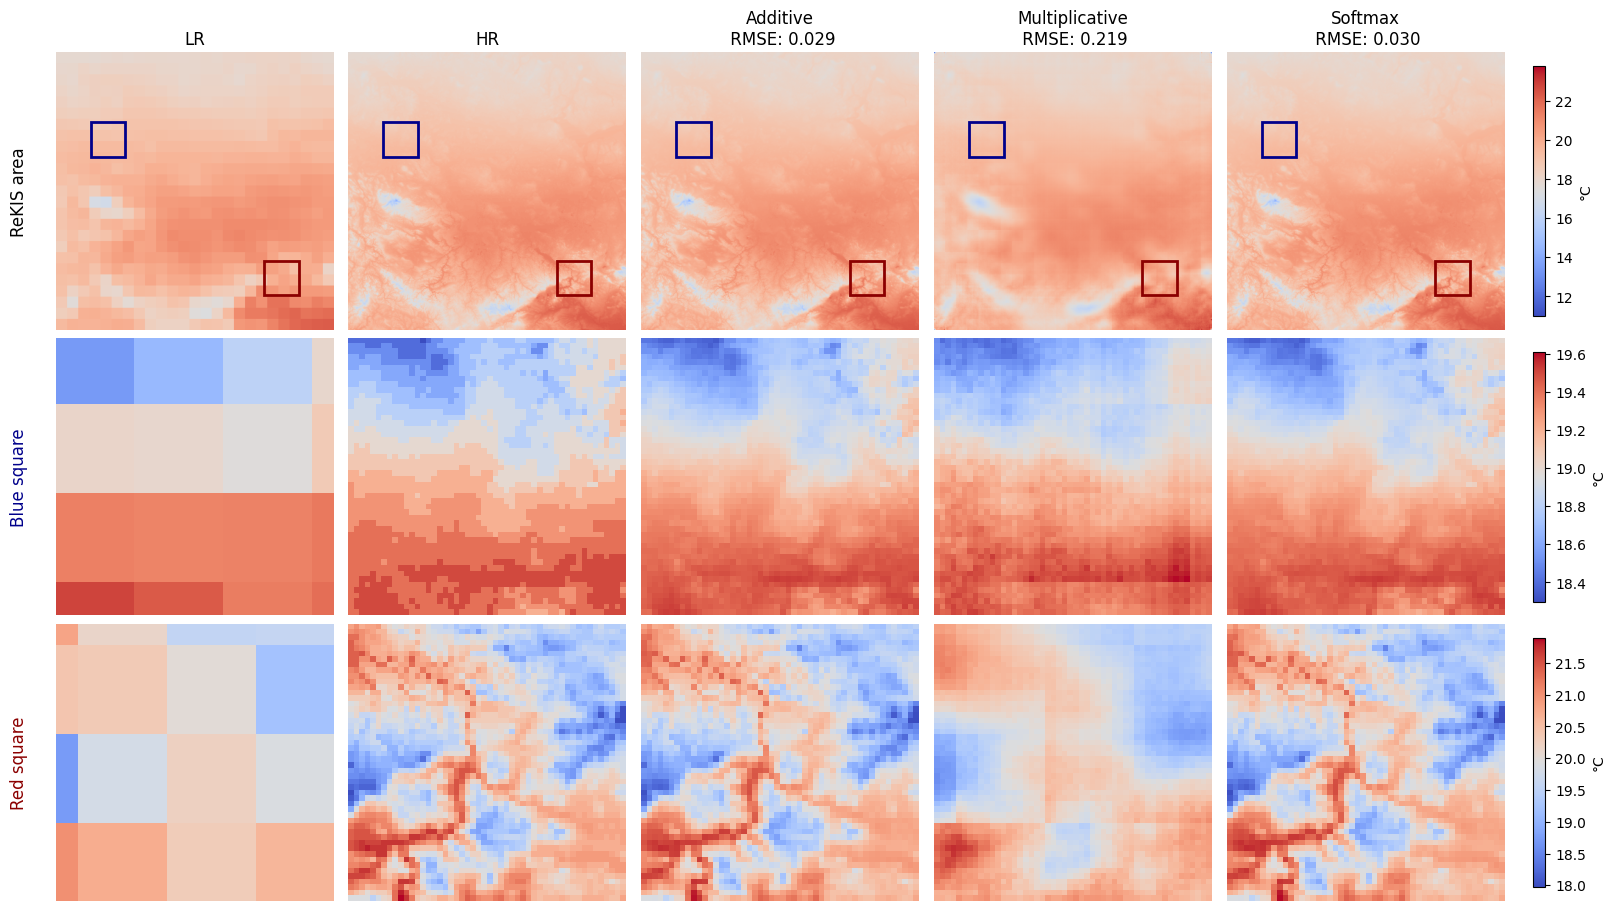

In [8]:
show_differences([np.kron(X.sel(time=DATE).values, np.ones((16, 16))), Y.sel(time=DATE).values, downscaled_add, downscaled_mult, downscaled_sm],
                 ['LR', 'HR', 'Additive', 'Multiplicative', 'Softmax'], 'hard_types_comp')

Multiplicative is bad, the other two seem to have no difference, but additive is better.

## Alpha value

In [9]:
ckpt = load_checkpoint(525)
model = models.EDSR.load_from_checkpoint(checkpoint_path = ckpt,
                                         channels=1,
                                         scale_factor=SCALE_FACTOR,
                                         features=128,
                                         residual_blocks=64,
                                         loss=loss.LossCombination([0.9999, 0.0001], [loss.L1Loss(), loss.SoftSimpleDerivativeLoss(SCALE_FACTOR)]),
                                         ).cuda()
model.eval()

downscaled_1e_minus_4 = downscale(X, DATE, model)

ckpt = load_checkpoint(518)
model = models.EDSR.load_from_checkpoint(checkpoint_path = ckpt,
                                         channels=1,
                                         scale_factor=SCALE_FACTOR,
                                         features=128,
                                         residual_blocks=64,
                                         loss=loss.LossCombination([0.001, 0.999], [loss.L1Loss(), loss.SoftSimpleDerivativeLoss(SCALE_FACTOR)]),
                                         ).cuda()
model.eval()

downscaled_9999e_minus_4 = downscale(X, DATE, model)

ckpt = load_checkpoint(526)
model = models.EDSR.load_from_checkpoint(checkpoint_path = ckpt,
                                         channels=1,
                                         scale_factor=SCALE_FACTOR,
                                         features=128,
                                         residual_blocks=64,
                                         loss=loss.LossCombination([1], [loss.L1Loss()]),
                                         ).cuda()
model.eval()

downscaled_0e = downscale(X, DATE, model)

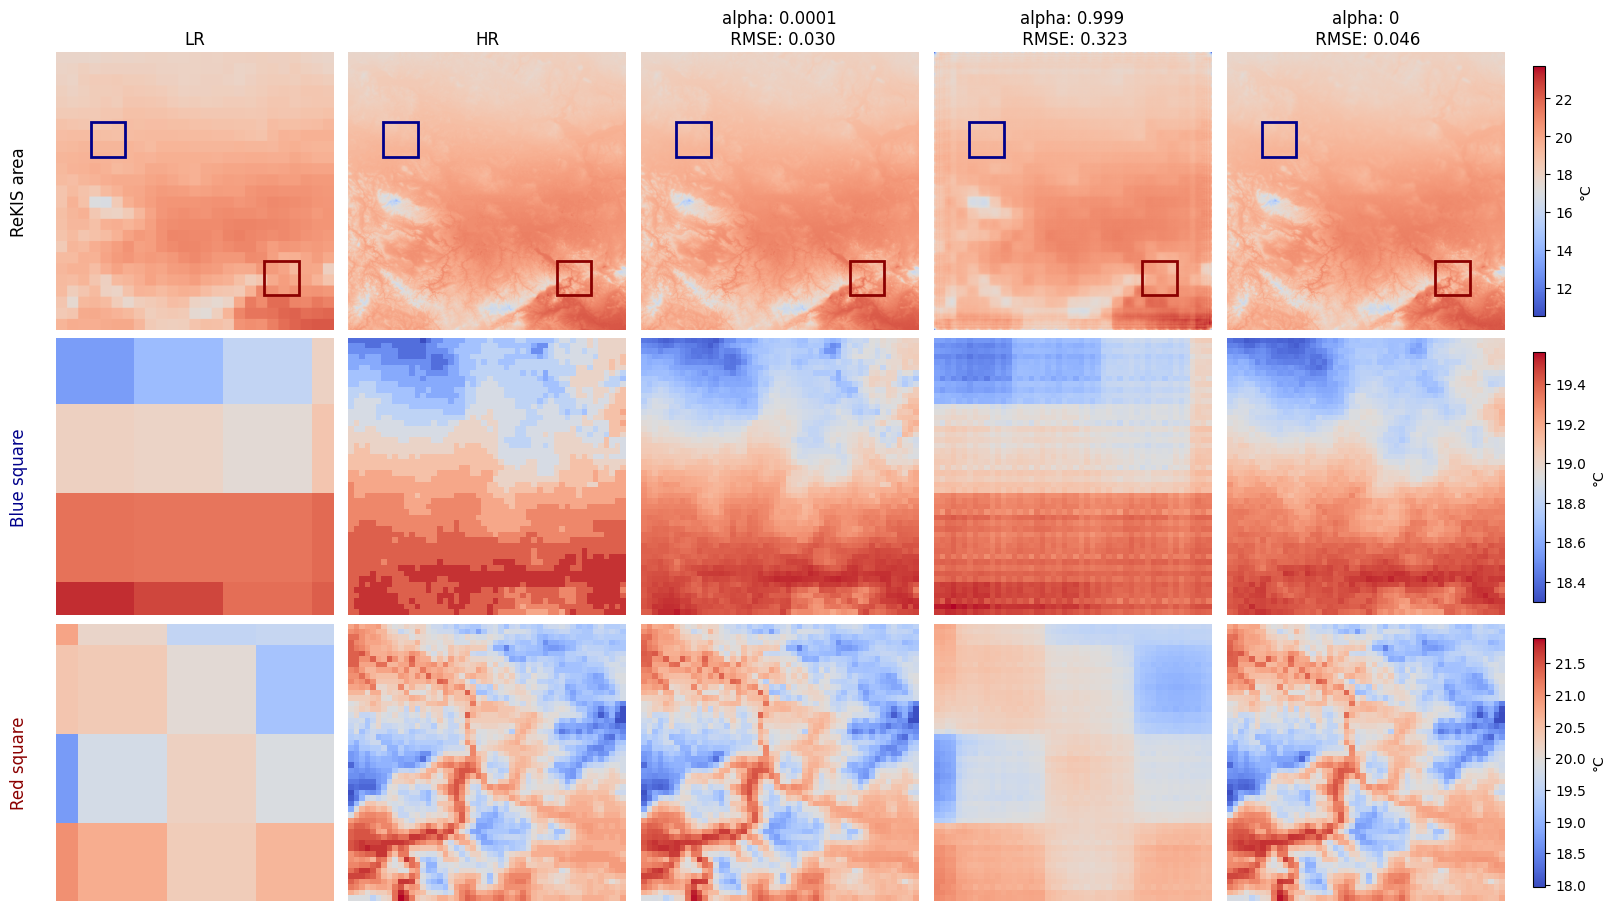

In [10]:
show_differences([np.kron(X.sel(time=DATE).values, np.ones((16, 16))), Y.sel(time=DATE).values, downscaled_1e_minus_4, downscaled_9999e_minus_4, downscaled_0e],
                 ['LR', 'HR', 'alpha: 0.0001', 'alpha: 0.999', 'alpha: 0'], 'alphas_comp')

High alpha 0.999 is bad, the difference between alpha 1e-4 and 0 is visible in the top right corner of the blue square, where the unconstrained model's output looks blurred compared to the other one.

## Constraint type

In [11]:
ckpt = load_checkpoint(559)
model = models.EDSR.load_from_checkpoint(checkpoint_path = ckpt,
                                         channels=1,
                                         scale_factor=SCALE_FACTOR,
                                         features=128,
                                         residual_blocks=64,
                                         loss=loss.LossCombination([0.9999, 0.0001], [loss.L1Loss(), loss.SoftGLoss(SCALE_FACTOR)]),
                                         ).cuda()
model.eval()

downscaled_gloss = downscale(X, DATE, model)

ckpt = load_checkpoint(515)
model = models.EDSR.load_from_checkpoint(checkpoint_path = ckpt,
                                         channels=1,
                                         scale_factor=SCALE_FACTOR,
                                         features=128,
                                         residual_blocks=64,
                                         loss=loss.LossCombination([0.9999, 0.0001], [loss.L1Loss(), loss.SoftGradientDirectionLoss(SCALE_FACTOR)]),
                                         ).cuda()
model.eval()

downscaled_simple_grad_dir = downscale(X, DATE, model)

ckpt = load_checkpoint(562)
model = models.EDSR.load_from_checkpoint(checkpoint_path = ckpt,
                                         channels=1,
                                         scale_factor=SCALE_FACTOR,
                                         features=128,
                                         residual_blocks=64,
                                         loss=loss.LossCombination([0.9999, 0.0001], [loss.L1Loss(), loss.SoftSobelGradientDirectionLoss(SCALE_FACTOR)]),
                                         ).cuda()
model.eval()

downscaled_sobel_grad_dir = downscale(X, DATE, model)

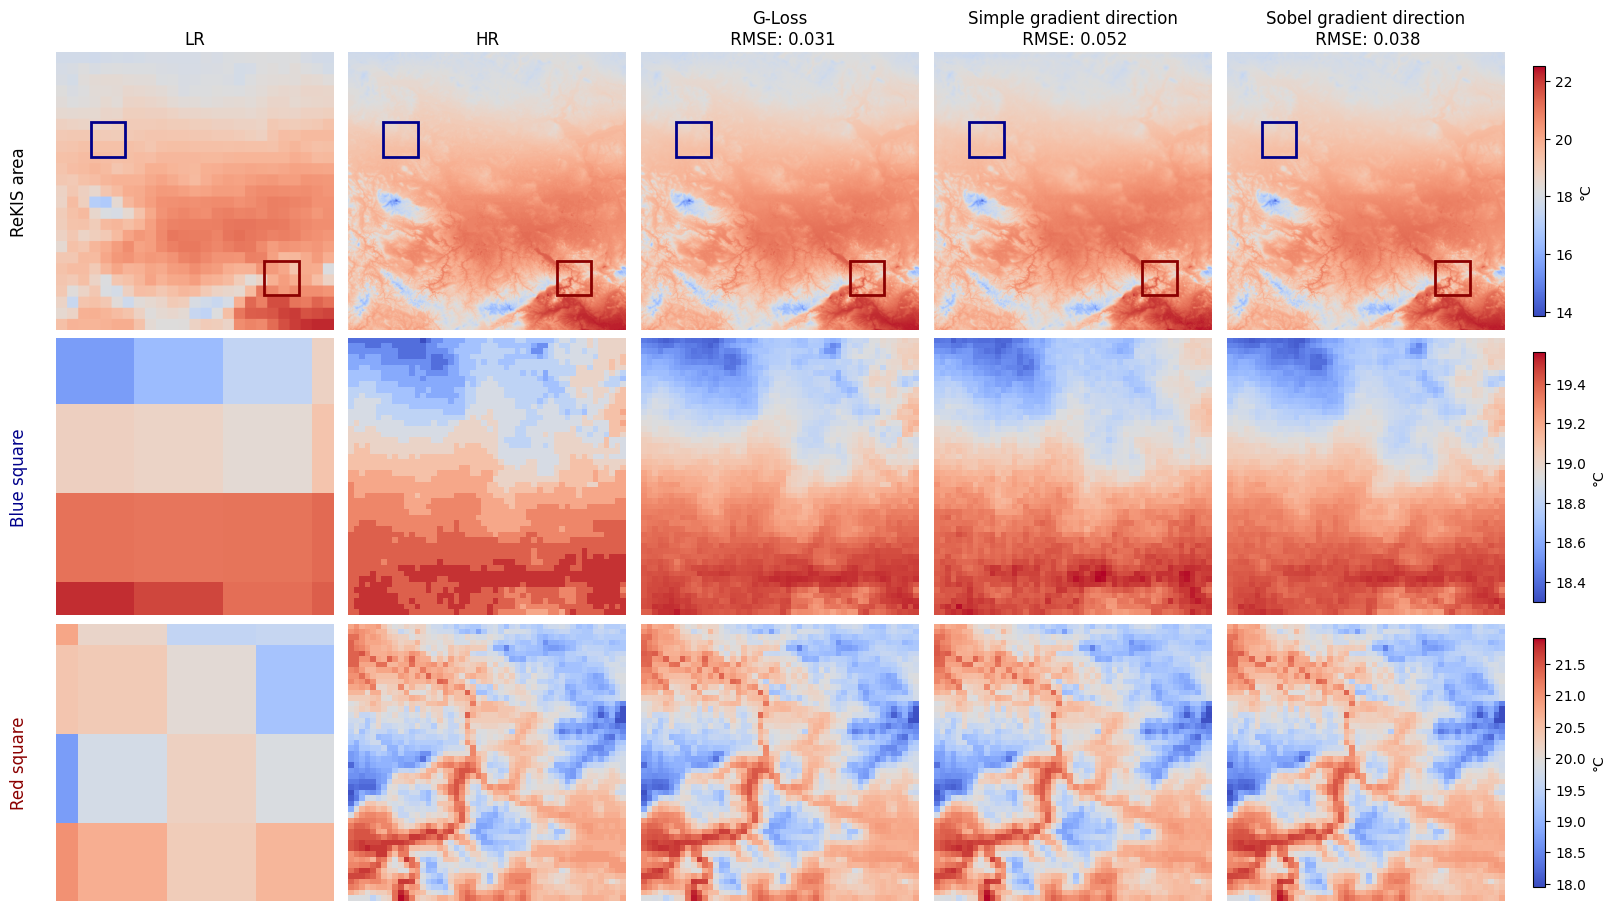

In [12]:
show_differences([np.kron(X.sel(time=DATE).values, np.ones((16, 16))), Y.sel(time=DATE).values, downscaled_gloss, downscaled_simple_grad_dir, downscaled_sobel_grad_dir],
                 ['LR', 'HR', 'G-Loss', 'Simple gradient direction', 'Sobel gradient direction'], 'soft_types_comp')

Again, top right corner of the blue square, the gradient direction approaches seem blurred compared to G-Loss.
## Sizes
### Sizes x constraints

In [13]:
ckpt = load_checkpoint(372)
model = models.EDSR.load_from_checkpoint(checkpoint_path = ckpt,
                                         channels=1,
                                         scale_factor=SCALE_FACTOR,
                                         features=128,
                                         residual_blocks=32,
                                         loss=loss.LossCombination([1], [loss.L1Loss()]),
                                         ).cuda()
model.eval()

downscaled_unc = downscale(X, DATE, model)

ckpt = load_checkpoint(624)
model = models.EDSR.load_from_checkpoint(checkpoint_path = ckpt,
                                         channels=1,
                                         scale_factor=SCALE_FACTOR,
                                         features=128,
                                         residual_blocks=32,
                                         loss=loss.LossCombination([0.9999, 0.0001], [loss.L1Loss(), loss.ConservationLoss(SCALE_FACTOR, 'mse')]),
                                         ).cuda()
model.eval()

downscaled_soft = downscale(X, DATE, model)

ckpt = load_checkpoint(395)
model = models.ConstrainedModel.load_from_checkpoint(checkpoint_path = ckpt,
                                                     model = models.EDSR(
                                         channels=1,
                                         scale_factor=SCALE_FACTOR,
                                         features=128,
                                         residual_blocks=32,
                                         loss=loss.LossCombination([1], [loss.L1Loss()]),
                                        ), constraint = models.AddConstraintLayer(SCALE_FACTOR)
                                                     ).cuda()
model.eval()

downscaled_hard = downscale(X, DATE, model)

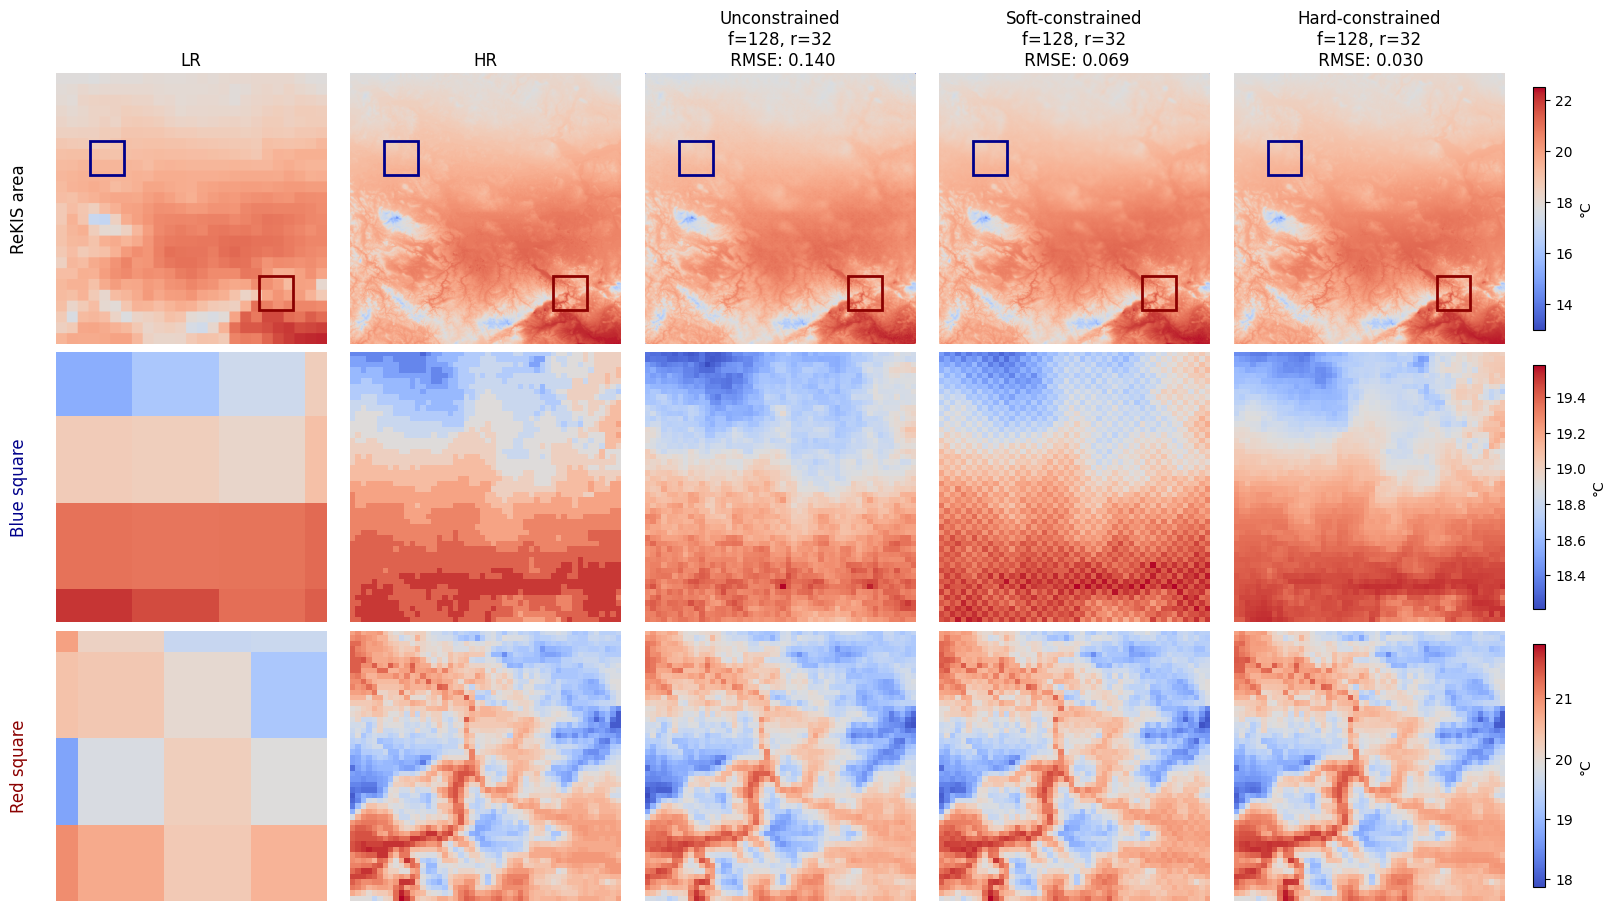

In [14]:
show_differences([np.kron(X.sel(time=DATE).values, np.ones((16, 16))), Y.sel(time=DATE).values, downscaled_unc, downscaled_soft, downscaled_hard],
                 ['LR', 'HR', 'Unconstrained\nf=128, r=32', 'Soft-constrained\nf=128, r=32', 'Hard-constrained\nf=128, r=32'], 'constraint_type_comp')

In smaller models, the hard-constrained one dominates. Other two of these models are showing signs of graining or some noise.

## Size x hard constraint

In [15]:
ckpt = load_checkpoint(308)
model = models.ConstrainedModel.load_from_checkpoint(checkpoint_path = ckpt,
                                                     model = models.EDSR(
                                         channels=1,
                                         scale_factor=SCALE_FACTOR,
                                         features=2,
                                         residual_blocks=2,
                                         loss=loss.LossCombination([1], [loss.L1Loss()]),
                                        ), constraint = models.AddConstraintLayer(SCALE_FACTOR)
                                                     ).cuda()
model.eval()

downscaled_f2_r2 = downscale(X, DATE, model)

ckpt = load_checkpoint(329)
model = models.ConstrainedModel.load_from_checkpoint(checkpoint_path = ckpt,
                                                     model = models.EDSR(
                                         channels=1,
                                         scale_factor=SCALE_FACTOR,
                                         features=16,
                                         residual_blocks=2,
                                         loss=loss.LossCombination([1], [loss.L1Loss()]),
                                        ), constraint = models.AddConstraintLayer(SCALE_FACTOR)
                                                     ).cuda()
model.eval()

downscaled_f16_r2 = downscale(X, DATE, model)

ckpt = load_checkpoint(332)
model = models.ConstrainedModel.load_from_checkpoint(checkpoint_path = ckpt,
                                                     model = models.EDSR(
                                         channels=1,
                                         scale_factor=SCALE_FACTOR,
                                         features=32,
                                         residual_blocks=2,
                                         loss=loss.LossCombination([1], [loss.L1Loss()]),
                                        ), constraint = models.AddConstraintLayer(SCALE_FACTOR)
                                                     ).cuda()
model.eval()

downscaled_f32_r2 = downscale(X, DATE, model)

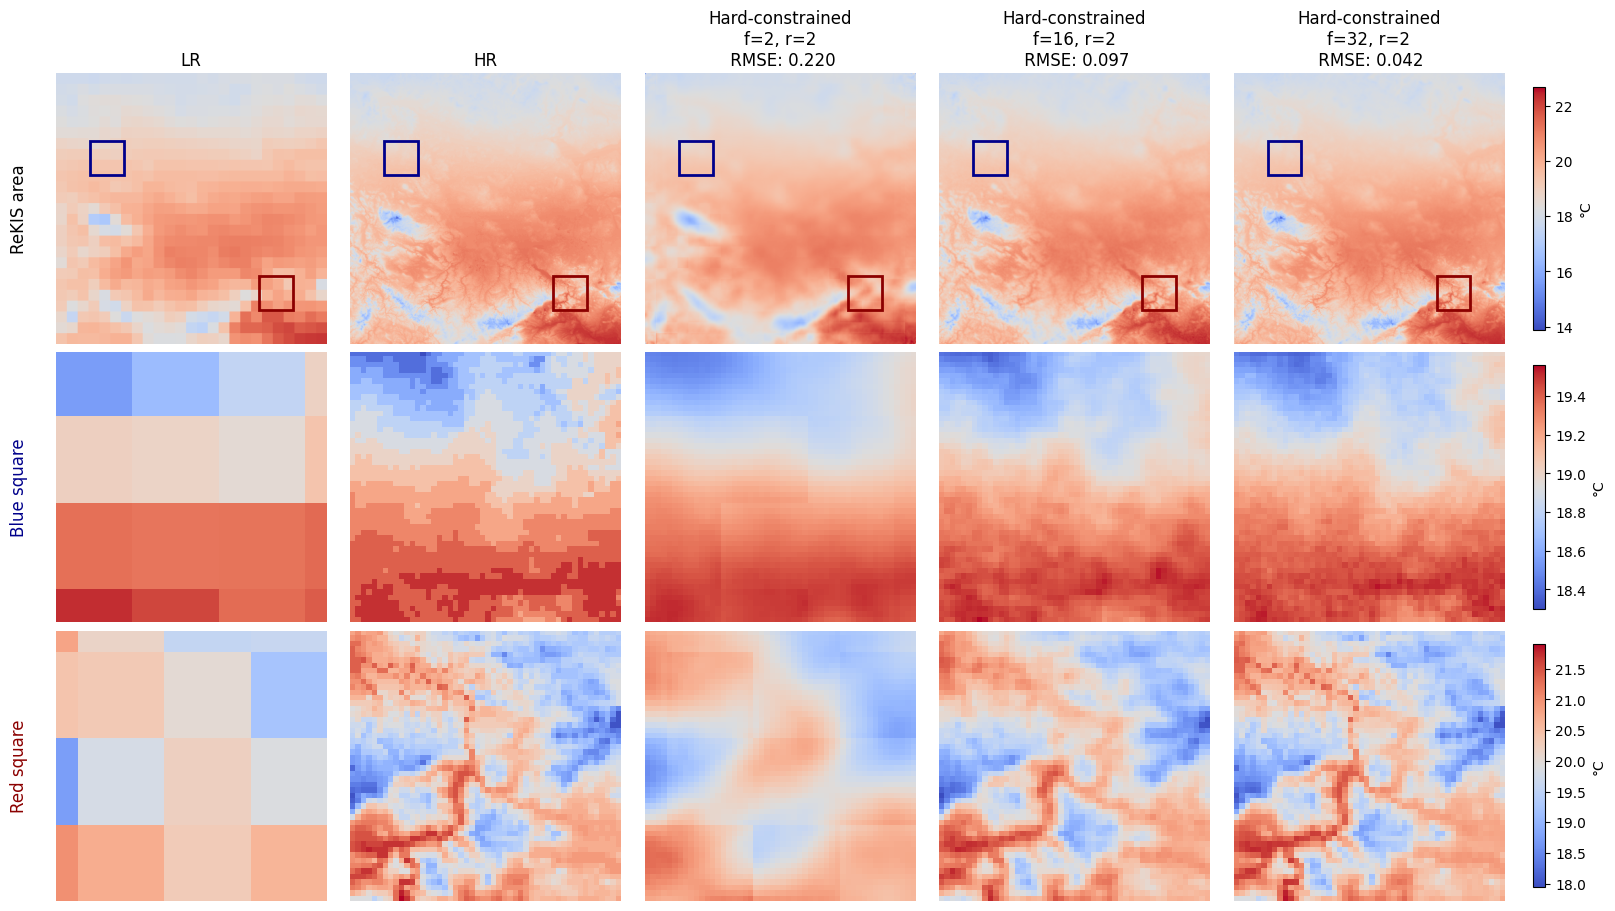

In [16]:
show_differences([np.kron(X.sel(time=DATE).values, np.ones((16, 16))), Y.sel(time=DATE).values, downscaled_f2_r2, downscaled_f16_r2, downscaled_f32_r2],
                 ['LR', 'HR', 'Hard-constrained\nf=2, r=2', 'Hard-constrained\nf=16, r=2', 'Hard-constrained\nf=32, r=2'], 'sizes_comp')

We test the performance of hard-cosntrained models for extremely small (from left to right with 837, 49K, 195K params) models compared to the best with f=128 and r=64 (21M params).
The smallest shown model is very blurred, but the largest model here (which is also tiny) makes solid performance, making hard to distinguish between thr HR and SR red regions.